# Implementing AI Governance Frameworks and Compliance

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand AI governance frameworks
- Implement compliance measures
- Apply regulatory guidelines
- Ensure ethical AI deployment
- Document governance practices

## 🔗 Where this fits

**Builds on:** Course 06 (AIAT 116) — Unit 5, lesson 03 "AI Governance Frameworks" — the frameworks; here the compliance work of actually running one.

**Used later in:** Course 11 (AIAT 125) — Unit 5 — monitoring, alerting and versioning, which is what compliance looks like in production.

---

This notebook covers practical activities from **Course 06, Unit 5**:
- Implementing AI governance frameworks and compliance

---

## Introduction

**AI governance frameworks** provide structures for ensuring responsible AI development and deployment, including compliance with regulations and ethical standards.


## 📌 The case: the AI Act stopped being a document and became a test suite

For most of its passage, the EU AI Act was something people *read*. In **October 2024** a team
from ETH Zurich, INSAIT and LatticeFlow AI published **COMPL-AI** (arXiv:2410.07959) — the
first technical interpretation of the Act, translating its broad legal requirements into
**measurable technical requirements**, together with an open-source benchmarking suite of
roughly 27 benchmarks.

They then ran it on **12 prominent large language models**. **None of them was fully compliant
with the Act's requirements**, with the clearest shortfalls in robustness, safety, diversity
and fairness — and the exercise also exposed gaps in the *benchmarks themselves*, which for
several requirements simply do not exist yet.

That is the shift this final notebook belongs to. Compliance is moving from prose that a
lawyer signs to **artefacts a pipeline produces**: a risk classification, a fairness
evaluation, an explanation capability, a defined human-oversight rule, an audit trail, a model
card, a DPIA, an incident playbook. Each of those is something you built earlier in this
course.

The deadlines are real and dated: **Article 5 prohibitions since 2 February 2025**,
general-purpose AI obligations since **2 August 2025**, most **high-risk obligations from
2 August 2026**, with fines up to **€35 million or 7 % of worldwide annual turnover** for
prohibited practices and **€15 million or 3 %** for other breaches (Article 99).

**The WHY.** A governance framework that lives in a PDF is checked when someone remembers. A
governance framework expressed as a function returns a score, blocks a merge, and cannot be
forgotten. You are about to run one against this course's own screening system — the model you
audited in Unit 2, explained in Unit 4, and logged decisions for in Unit 4 Notebook 04 — and
it is going to fail.

---


date          newly in force                                                active
----------------------------------------------------------------------------------------
2024-08-01    Regulation enters into force (nothing applies yet)            0/6
2025-02-02    Prohibitions (Art. 5), AI literacy duty (Art. 4)              2/6
2025-08-02    GPAI model obligations (Ch. V), Governance bodies + penalties 4/6
2026-08-02    High-risk: Annex III use cases                                5/6
2027-08-02    High-risk: Annex I products                                   6/6

Today is 2026-08-30: 5 of 6 blocks are already in force.


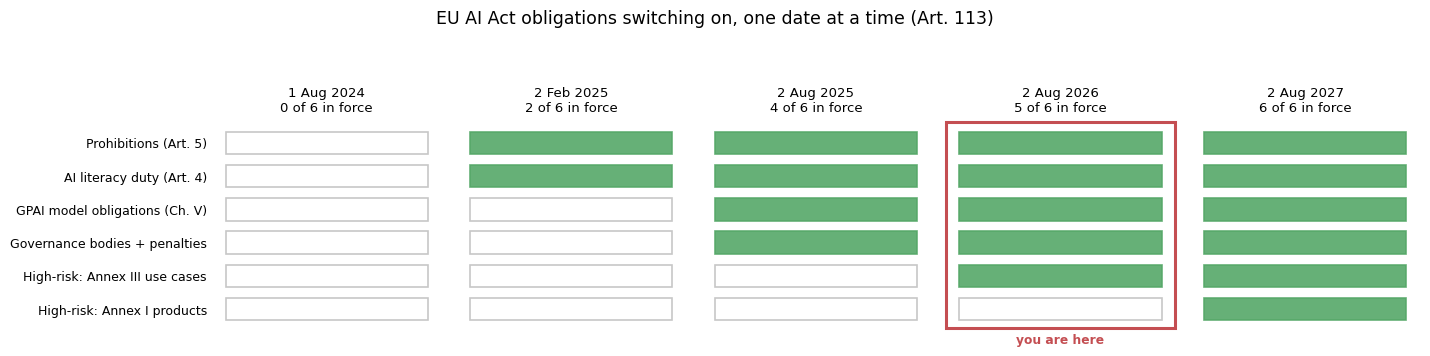

In [1]:
# WHAT this cell draws: a five-frame storyboard of the EU AI Act switching on -
# one panel per application date, a green block for every obligation already in
# force on that date - plus the step table underneath it.
# WHY: the paragraph above lists four dates. A list of dates does not show that
# the Act arrives in pieces, that most of it was NOT in force when it "entered
# into force", or where today sits in the sequence. Five panels do.
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from datetime import date

# Application dates from Article 113 of the Regulation as adopted. Regulation
# gets amended - re-check these before relying on them (see "Where this breaks").
BLOCKS = [("Prohibitions (Art. 5)",           date(2025, 2, 2)),
          ("AI literacy duty (Art. 4)",       date(2025, 2, 2)),
          ("GPAI model obligations (Ch. V)",  date(2025, 8, 2)),
          ("Governance bodies + penalties",   date(2025, 8, 2)),
          ("High-risk: Annex III use cases",  date(2026, 8, 2)),
          ("High-risk: Annex I products",     date(2027, 8, 2))]
FRAMES = [date(2024, 8, 1), date(2025, 2, 2), date(2025, 8, 2),
          date(2026, 8, 2), date(2027, 8, 2)]
today = date.today()
cur = max(i for i, f in enumerate(FRAMES) if f <= today) if FRAMES[0] <= today else -1

# The step table: exactly what each frame of the storyboard shows.
print(f"{'date':<14}{'newly in force':<62}{'active'}")
print("-" * 88)
for f in FRAMES:
    new = [b for b, d in BLOCKS if d == f]
    act = sum(1 for _, d in BLOCKS if d <= f)
    label = ', '.join(new) if new else 'Regulation enters into force (nothing applies yet)'
    print(f"{f.isoformat():<14}{label:<62}{act}/6")
print(f"\nToday is {today.isoformat()}: {sum(1 for _, d in BLOCKS if d <= today)} "
      f"of 6 blocks are already in force.")

fig, axes = plt.subplots(1, len(FRAMES), figsize=(14.4, 3.6), sharey=True)
for k, (ax, f) in enumerate(zip(axes, FRAMES)):
    n = 0
    for i, (lab, d) in enumerate(BLOCKS):
        on = d <= f                                  # in force on this frame's date?
        n += int(on)
        ax.add_patch(Rectangle((0.06, i - 0.34), 0.88, 0.68,
                               facecolor="#55A868" if on else "none",
                               edgecolor="#55A868" if on else "0.78", lw=1.2,
                               alpha=0.9 if on else 1))
    ax.set_xlim(0, 1)
    ax.set_ylim(len(BLOCKS) - 0.4, -0.7)             # first block at the top
    ax.set_xticks([])
    ax.set_yticks(range(len(BLOCKS)))
    ax.set_title(f"{f.strftime('%d %b %Y').lstrip('0')}\n{n} of 6 in force", fontsize=9.5)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
    if k == cur:                                     # highlight today's state
        ax.add_patch(Rectangle((0.0, -0.62), 1.0, len(BLOCKS) + 0.2, fill=False,
                               edgecolor="#C44E52", lw=2.2, clip_on=False))
        ax.text(0.5, 5.72, "you are here", ha="center", va="top",
                fontsize=8.8, color="#C44E52", fontweight="bold")
axes[0].set_yticklabels([b for b, _ in BLOCKS], fontsize=9)
fig.suptitle("EU AI Act obligations switching on, one date at a time (Art. 113)",
             fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


**What to see in this storyboard.** Five panels, same six rows, read left to right. The green
blocks are the obligations already in force on that panel's date; the empty outlines are the
ones still to come. Count them along the top: **0, 2, 4, 5, 6 of 6.**

Panel 1 is the surprise worth pausing on. On **1 August 2024** the Act "entered into force" and
**not one row is green** — nothing applied to anybody yet. Prohibitions and the AI literacy duty
switch on in panel 2; general-purpose AI obligations, the governance bodies and the penalty
regime in panel 3; the Annex III high-risk duties — the tier this course's own screening model
falls into — in panel 4; and the Annex I product rules last, in panel 5.

The red box marks the panel matching **the date you are running this notebook**, and the step
table above prints the same sequence in words. Two working conclusions: "the AI Act is in force"
tells you almost nothing on its own, and the row that matters to you has its own date.



## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [2]:
# Concept map: the three layers of AI governance before implementing one below.
# Why first: the hands-on cell turns each of these bullets into working code.

print("✅ Libraries imported!")
print("\nAI Governance Frameworks")
print("=" * 60)

# Layer 1 - what an organization must HAVE: policies, risk management, monitoring.
print("\nGovernance Components:")
print("  - Policy frameworks")
print("  - Risk management")
print("  - Compliance monitoring")
print("  - Ethical guidelines")

# Layer 2 - what the outside world REQUIRES: laws, standards, industry rules.
print("\nRegulatory Compliance:")
print("  - GDPR compliance")
print("  - AI Act compliance")
print("  - Industry standards")
print("  - Best practices")

# Layer 3 - how it becomes REAL: structures, checks, documentation, audits.
print("\nImplementation:")
print("  - Governance structures")
print("  - Compliance checks")
print("  - Documentation")
print("  - Auditing")

print("\n✅ AI governance concepts understood!")

✅ Libraries imported!

AI Governance Frameworks

Governance Components:
  - Policy frameworks
  - Risk management
  - Compliance monitoring
  - Ethical guidelines

Regulatory Compliance:
  - GDPR compliance
  - AI Act compliance
  - Industry standards
  - Best practices

Implementation:
  - Governance structures
  - Compliance checks
  - Documentation
  - Auditing

✅ AI governance concepts understood!


In [3]:
# Why as code: a compliance checklist that runs is one your CI pipeline can
# enforce - governance stops being a PDF and becomes a gate.

# Practice: implement a compliance checker + a governance record

from datetime import date

# Requirements checklist distilled from EU AI Act high-risk obligations + GDPR
REQUIREMENTS = {
    'risk_classification_done':   'Classify the system (EU AI Act tiers - Nb. 01)',
    'fairness_evaluated':         'Fairness metrics by group (Unit 2)',
    'privacy_dpia_done':          'Data protection impact assessment (Unit 3)',
    'explainability_available':   'Explanations for decisions (Unit 4: SHAP/LIME/CF)',
    'human_oversight_defined':    'HITL routing for significant decisions (Unit 4)',
    'audit_logging_enabled':      'Decision audit trail (Unit 4)',
    'documentation_current':      'Model card + technical documentation (Unit 4)',
    'incident_process_defined':   'Rollback + disclosure playbook (Nb. 03)',
}

def check_compliance(system_profile):
    """Return (met, gaps) for a system profile against REQUIREMENTS."""
    met = {k: v for k, v in REQUIREMENTS.items() if system_profile.get(k, False)}
    gaps = {k: v for k, v in REQUIREMENTS.items() if not system_profile.get(k, False)}
    return met, gaps

# Profile of the system this course actually built across Units 2-4: the
# screening model trained on the real Titanic manifest (891 real passengers).
# Each flag records what we genuinely did in those units - including what we did
# not do, because a governance record that only lists successes is worthless.
screening_system = {
    'name': 'screening-rf-v1.0 (Units 2-4 course demo, real Titanic data)',
    'risk_classification_done': True,    # High risk (triage-style screening) - Nb. 01
    'fairness_evaluated': True,          # Unit 2: measured on the real sex disparity
    'privacy_dpia_done': False,          # never did a DPIA for it (Unit 3 taught the pieces)
    'explainability_available': True,    # Unit 4 Nbs. 01-03
    'human_oversight_defined': True,     # Unit 4 Nb. 05
    'audit_logging_enabled': True,       # Unit 4 Nb. 04
    'documentation_current': True,       # model card - Unit 4 Nb. 06
    'incident_process_defined': False,   # nothing yet
}

met, gaps = check_compliance(screening_system)
print("=" * 80)
print(f"COMPLIANCE CHECK: {screening_system['name']}")
print("=" * 80)
print(f"\n✅ Met ({len(met)}/{len(REQUIREMENTS)}):")
for k, v in met.items():
    print(f"   - {k}: {v}")
print(f"\n❌ Gaps ({len(gaps)}/{len(REQUIREMENTS)}):")
for k, v in gaps.items():
    print(f"   - {k}: {v}")
score = len(met) / len(REQUIREMENTS)
print(f"\nCompliance score: {score:.0%}")
print("Verdict:", "ready for governance review" if score >= 0.9
      else "NOT ready - close the gaps above first")

# --- Governance record: the documentation trail regulators ask for ---
governance_record = {
    'system': screening_system['name'],
    'review_date': str(date.today()),
    'risk_tier': 'High risk (triage-style screening of people, EU AI Act Annex III)',
    'compliance_score': f"{score:.0%}",
    'open_gaps': list(gaps.keys()),
    'accountable_owner': 'ML Lead (per RACI - Unit 4 Nb. 04)',
    'next_review': 'Quarterly, or on any model retrain',
}
print("\nGOVERNANCE RECORD (what gets filed):")
for k, v in governance_record.items():
    print(f"  {k:>18}: {v}")
print("\n✅ Governance implemented as running code: check -> score -> document -> review.")

COMPLIANCE CHECK: screening-rf-v1.0 (Units 2-4 course demo, real Titanic data)

✅ Met (6/8):
   - risk_classification_done: Classify the system (EU AI Act tiers - Nb. 01)
   - fairness_evaluated: Fairness metrics by group (Unit 2)
   - explainability_available: Explanations for decisions (Unit 4: SHAP/LIME/CF)
   - human_oversight_defined: HITL routing for significant decisions (Unit 4)
   - audit_logging_enabled: Decision audit trail (Unit 4)
   - documentation_current: Model card + technical documentation (Unit 4)

❌ Gaps (2/8):
   - privacy_dpia_done: Data protection impact assessment (Unit 3)
   - incident_process_defined: Rollback + disclosure playbook (Nb. 03)

Compliance score: 75%
Verdict: NOT ready - close the gaps above first

GOVERNANCE RECORD (what gets filed):
              system: screening-rf-v1.0 (Units 2-4 course demo, real Titanic data)
         review_date: 2026-08-30
           risk_tier: High risk (triage-style screening of people, EU AI Act Annex III)
    complian

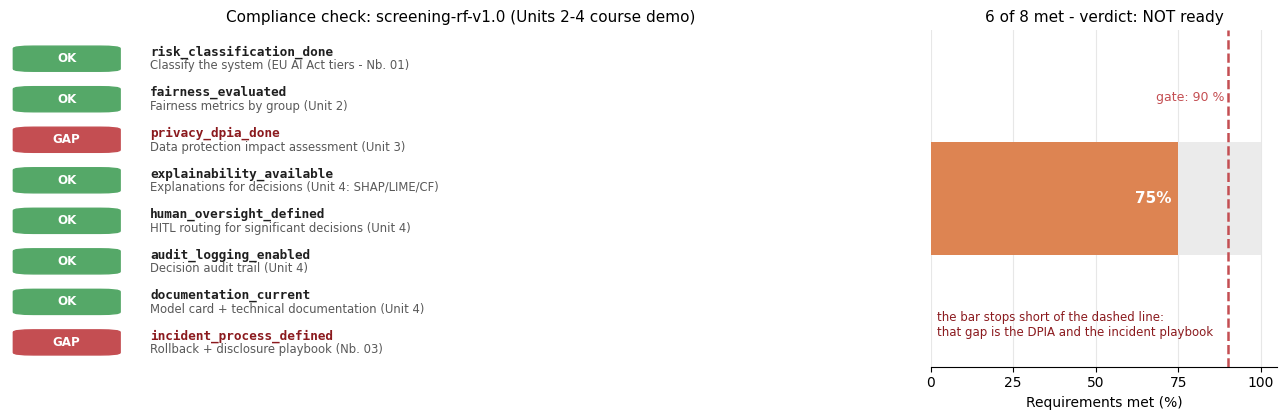

In [4]:
# WHAT this cell draws: the compliance check you just ran, as a scorecard - each
# requirement marked OK or GAP, and the overall score against the gate that decides
# the verdict.
# WHY: the printed output separates the met list from the gap list, so the two
# never appear side by side. On one card you can see both, and you can see how far
# 75 % actually is from the 90 % the verdict rule demands.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.2, 4.3),
                               gridspec_kw={"width_ratios": [2.6, 1.0]})

# --- Left: the eight requirements, in the order REQUIREMENTS defines them -------
for i, (k, desc) in enumerate(REQUIREMENTS.items()):
    ok = bool(screening_system.get(k, False))
    col = "#55A868" if ok else "#C44E52"
    axL.add_patch(FancyBboxPatch((0.02, i - 0.30), 0.30, 0.60,
                                 boxstyle="round,pad=0.01,rounding_size=0.06",
                                 facecolor=col, edgecolor=col))
    axL.text(0.17, i, "OK" if ok else "GAP", ha="center", va="center",
             color="white", fontsize=8.6, fontweight="bold")
    axL.text(0.42, i - 0.16, k, va="center", fontsize=9.2, fontweight="bold",
             color="0.12" if ok else "#8B1A1E", family="monospace")
    axL.text(0.42, i + 0.18, desc, va="center", fontsize=8.4, color="0.35")
axL.set_xlim(0, 2.7)
axL.set_ylim(len(REQUIREMENTS) - 0.4, -0.7)
axL.axis("off")
axL.set_title(f"Compliance check: {screening_system['name'].split(' (')[0]} "
              f"(Units 2-4 course demo)", fontsize=11)

# --- Right: the score against the 90 % gate that produces the verdict -----------
axR.barh([0], [100], color="0.92", height=0.5)          # the whole checklist
axR.barh([0], [score * 100], color="#DD8452", height=0.5)
axR.axvline(90, color="#C44E52", ls="--", lw=1.8)
axR.text(89, 0.42, "gate: 90 %", ha="right", va="bottom", fontsize=9, color="#C44E52")
axR.text(score * 100 - 2, 0, f"{score:.0%}", ha="right", va="center", color="white",
         fontsize=11, fontweight="bold")
axR.set_xlim(0, 105)
axR.set_ylim(-0.75, 0.75)
axR.set_yticks([])
axR.set_xticks([0, 25, 50, 75, 100])
axR.set_xlabel("Requirements met (%)")
axR.set_title(f"{len(met)} of {len(REQUIREMENTS)} met - verdict: NOT ready", fontsize=11)
axR.text(2, -0.5, "the bar stops short of the dashed line:\n"
                  "that gap is the DPIA and the incident playbook",
         fontsize=8.5, color="#8B1A1E", va="top")
for s in ("top", "right", "left"):
    axR.spines[s].set_visible(False)
axR.grid(axis="x", alpha=0.3)
axR.set_axisbelow(True)
fig.tight_layout()
plt.show()


**What to see in this figure.** *Left:* eight rows, six green **OK** and two red **GAP**. The
two red ones are `privacy_dpia_done` and `incident_process_defined` — and notice what they have
in common: every green row is an artefact somebody built while making the model, and both red
rows are artefacts somebody has to sit down and write *about* the model. That is the shape of
most real compliance gaps.

*Right:* the orange bar reaches **75 %** and the dashed red line is the **90 %** the verdict rule
demands. The gap between the end of the bar and the line is the whole reason the printed verdict
says NOT ready — two checkboxes, worth 25 percentage points, on a scale where each box is worth
12.5. That last number is the honest one to argue with in the Discuss below: on this scorecard a
missing rollback playbook and a missing fairness evaluation cost exactly the same.



## 💬 Discuss — the last argument of the course

Your compliance checker scored the course's own system **75 % (6 of 8)**, verdict **NOT
ready**, with two gaps: **`privacy_dpia_done`** (Unit 3) and **`incident_process_defined`**
(Notebook 03).

1. **Would you block the release?** The system meets six of eight requirements including
   fairness evaluation, explainability, human oversight, audit logging and documentation. The
   two gaps are a missing impact assessment and a missing rollback-and-disclosure playbook.
   A product manager argues that both are paperwork and can follow in the next sprint. Answer
   them. Then say what your answer would be if the system were a chatbot recommending films,
   and if it were a triage tool in an emergency department — and what makes those different in
   a way you could write into a rule.
2. **Where should this check live?** As a notebook cell, it runs when someone remembers. As a
   CI gate, it blocks the merge — and teams route around gates that block them. As a
   quarterly audit, it catches things late. Pick a place, and describe what happens the first
   time it blocks a release the business badly wants. Who has the authority to override, and
   is the override logged?
3. **Eight booleans for a whole ethics course.** Units 1–5 taught contested frameworks,
   metrics that disagree by mathematical necessity, privacy budgets nobody can interpret,
   explanations that can be engineered to lie, and a regulatory landscape that changes every
   quarter. This cell reduces all of it to 6/8. What does the reduction buy, what does it
   destroy, and which single item would you add to make the score harder to game? Argue it
   properly — this is the question the rest of your career will keep asking.


---

## 🎉 Course Completion: You've Mastered AI Ethics!

### What We've Accomplished

We've completed **Course 06: AI Ethics**! We've learned:

**Unit 1: Ethics Foundations**
- ✅ Ethical frameworks (utilitarianism, deontology, virtue ethics)
- ✅ Ethical decision-making frameworks
- ✅ Case study analysis (COMPAS)

**Unit 2: Bias and Justice**
- ✅ Bias detection in AI systems
- ✅ Bias mitigation techniques
- ✅ Fair representation learning
- ✅ Fair AI development

**Unit 3: Privacy and Security**
- ✅ Data protection strategies
- ✅ Privacy-enhancing technologies (PETs)
- ✅ Differential privacy
- ✅ GDPR compliance
- ✅ Secure AI development

**Unit 4: Transparency and Accountability**
- ✅ SHAP and LIME explanations
- ✅ Counterfactual analysis
- ✅ Accountability frameworks
- ✅ Human-in-the-loop approaches
- ✅ Transparency tools

**Unit 5: Governance and Regulations**
- ✅ Global AI regulations
- ✅ Industry-specific regulations
- ✅ Governance frameworks
- ✅ Legal challenges

### The Complete Ethical AI Toolkit

You now have a complete toolkit for building ethical AI systems:
- **Ethics**: Understand ethical principles and decision-making
- **Fairness**: Detect, mitigate, and prevent bias
- **Privacy**: Protect data and ensure privacy compliance
- **Transparency**: Explain AI decisions and ensure accountability
- **Governance**: Navigate regulations and implement governance

### Congratulations! 🎉

**You've completed Course 06: AI Ethics!** You now understand:
- ✅ How to build fair, private, secure, transparent, and compliant AI systems
- ✅ How to navigate the ethical landscape of AI
- ✅ How to implement ethical AI practices in real-world scenarios

**You're now equipped to build ethical AI systems that:**
- Respect human rights and dignity
- Ensure fairness and justice
- Protect privacy and security
- Provide transparency and accountability
- Comply with regulations and governance requirements

**Well done!** 🌟 You've mastered the essential skills for ethical AI development!

## ⚠️ Where this breaks — and what to carry out of this course

- **A green compliance score is a floor, not a verdict.** COMPL-AI found that none of twelve
  leading models met the Act's requirements, *and* that for several requirements the
  benchmarks needed to check them do not yet exist. A checker can only test what someone knew
  how to encode. Yours tests eight things; the interesting failures are always the ninth.
- **Booleans hide judgement.** `fairness_evaluated = True` says a fairness evaluation happened.
  It does not say which metric (Unit 2: they disagree, by proof), on which groups, at what
  sample size, or whether the result was acceptable. Every item in this checklist has that
  problem, and the more automatable the check, the more it hides.
- **Checks that gate get gamed.** The moment a score blocks a release, the incentive shifts
  from *being compliant* to *scoring compliant*. Expect a `docs/model_card.md` containing a
  heading and nothing else. Any check that matters needs a human spot-audit of the artefact,
  not just its existence.
- **Compliance and ethics are different questions, and this course has taught both.** COMPAS
  was lawful. The Dutch childcare model was operated by a government following its own
  procedures. Clearview's scraping was legal until somebody wrote it down as illegal. The
  checklist tells you whether you *may* proceed; Unit 1 asks whether you *should*.
- **Everything here has a date on it.** The AI Act phases in through 2027; guidance,
  harmonised standards and enforcement practice are still arriving; the Saudi PDPL entered
  full enforcement in September 2024 and SDAIA's practice is developing. Re-check before you
  rely on any of it.

**The cheapest thing that works, and the one to remember:** for any system that affects a
person's liberty, money, health or employment, produce three artefacts before launch — a
**disaggregated evaluation with group sizes**, a **named accountable owner**, and a **route by
which the affected person can contest the decision and reach a human**. That is most of this
course, it is affordable at any team size, and it is what was missing in every case study you
studied: COMPAS, Gender Shades, Obermeyer's health algorithm, the *toeslagenaffaire*, Horizon,
Robodebt and Tempe.


## 📚 References

1. NIST (2023). *Artificial Intelligence Risk Management Framework (AI RMF 1.0)*. NIST AI 100-1. <https://www.nist.gov/itl/ai-risk-management-framework>
2. European Parliament & Council (2024). *Regulation (EU) 2024/1689 — the EU AI Act*. <https://digital-strategy.ec.europa.eu/en/policies/regulatory-framework-ai>
3. Raji, I. D., Smart, A., White, R. N., et al. (2020). *Closing the AI Accountability Gap: Defining an End-to-End Framework for Internal Algorithmic Auditing*. FAT* 2020. <https://arxiv.org/abs/2001.00973>
4. Jobin, A., Ienca, M. & Vayena, E. (2019). *The Global Landscape of AI Ethics Guidelines*. Nature Machine Intelligence, 1, 389–399. <https://doi.org/10.1038/s42256-019-0088-2>
5. Guldimann, P., Spiridonov, A., Staab, R., Jovanović, N., Vero, M., Vechev, V., et al. (2024). *COMPL-AI Framework: A Technical Interpretation and LLM Benchmarking Suite for the EU Artificial Intelligence Act*. arXiv:2410.07959 — the study described in this notebook's opening case. <https://arxiv.org/abs/2410.07959>
6. Ghosh, A., et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. arXiv:2606.09809. <https://arxiv.org/abs/2606.09809>
